In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning models and metrics
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [10]:
# Option A: Load your Kaggle dataset CSV file
df = pd.read_csv('sales_data.csv')

# Option B: Create a simple 2-year sample sales dataset (Runs instantly anywhere!)
np.random.seed(42)
dates = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')

# Simple trend + seasonal pattern + random noise
sales = 500 + np.arange(len(dates)) * 0.5 + np.sin(np.arange(len(dates)) / 30) * 50 + np.random.normal(0, 20, len(dates))

df = pd.DataFrame({
    'Date': dates.strftime('%Y-%m-%d'),
    'Sales': sales
})

# Add a few missing values to practice preprocessing
df.loc[[10, 25, 50], 'Sales'] = np.nan

# Display first 5 rows
print("Dataset preview:")
df.head()

Dataset preview:


,Date,Sales
0,2022-01-01,509.934283
1,2022-01-02,499.401072
2,2022-01-03,517.284636
3,2022-01-04,536.952268
4,2022-01-05,503.963864


Dataset Shape: (730, 2)

Missing values count:
Date     0
Sales    3
dtype: int64


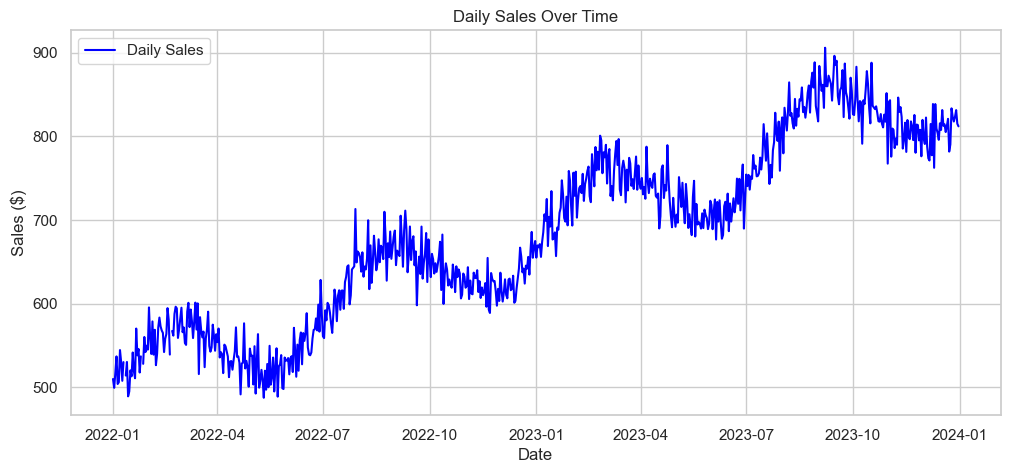

In [11]:
# Check dataset shape and data types
print(f"Dataset Shape: {df.shape}")
print("\nMissing values count:")
print(df.isnull().sum())

# Plot raw sales over time
plt.figure(figsize=(12, 5))
plt.plot(pd.to_datetime(df['Date']), df['Sales'], color='blue', label='Daily Sales')
plt.title('Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.show()

## Step 3: Data Preprocessing & Feature Extraction

In [12]:
# 1. Handle missing values by forward-filling (ffill)
df['Sales'] = df['Sales'].fillna(method='ffill')
print("Missing values after cleaning:", df['Sales'].isnull().sum())

# 2. Convert Date column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# 3. Extract simple date features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 5 else 0)

# Preview processed dataset
df.head()

Missing values after cleaning: 0


C:\Users\tirth\AppData\Local\Temp\ipykernel_22028\3737663057.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Sales'] = df['Sales'].fillna(method='ffill')


,Date,Sales,Year,Month,Day,DayOfWeek,Is_Weekend
0,2022-01-01,509.934283,2022,1,1,5,1
1,2022-01-02,499.401072,2022,1,2,6,1
2,2022-01-03,517.284636,2022,1,3,0,0
3,2022-01-04,536.952268,2022,1,4,1,0
4,2022-01-05,503.963864,2022,1,5,2,0


In [13]:
# Define Features (X) and Target (y)
features = ['Year', 'Month', 'Day', 'DayOfWeek', 'Is_Weekend']
X = df[features]
y = df['Sales']

# Chronological Train-Test Split (80% Train, 20% Test)
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
test_dates = df['Date'].iloc[split_index:]

print(f"Training rows: {len(X_train)}")
print(f"Testing rows: {len(X_test)}")

Training rows: 584
Testing rows: 146


In [14]:
# Model 1: Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Model 2: Random Forest Regressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


In [15]:
# Function to calculate evaluation metrics
def evaluate(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# Calculate metrics
lr_rmse, lr_mae, lr_r2 = evaluate(y_test, lr_preds)
rf_rmse, rf_mae, rf_r2 = evaluate(y_test, rf_preds)

# Print comparison table
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [lr_rmse, rf_rmse],
    'MAE': [lr_mae, rf_mae],
    'R² Score': [lr_r2, rf_r2]
})

print("=== Model Evaluation Summary ===")
results_df.round(2)

=== Model Evaluation Summary ===


,Model,RMSE,MAE,R² Score
0,Linear Regression,49.33,39.92,-1.83
1,Random Forest,30.86,24.49,-0.11


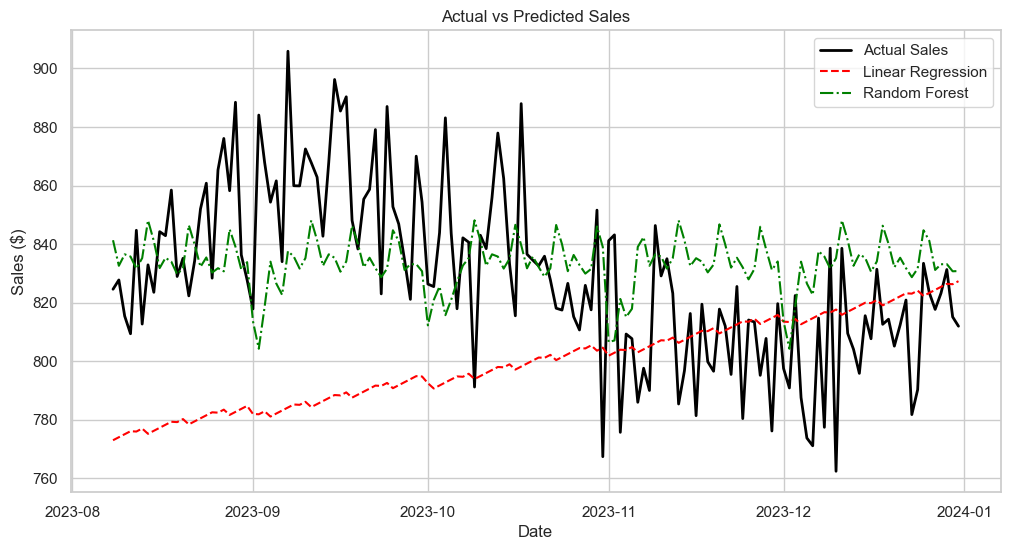

In [16]:
# Plot Actual Sales vs Model Predictions
plt.figure(figsize=(12, 6))
plt.plot(test_dates, y_test, label='Actual Sales', color='black', linewidth=2)
plt.plot(test_dates, lr_preds, label='Linear Regression', color='red', linestyle='--')
plt.plot(test_dates, rf_preds, label='Random Forest', color='green', linestyle='-.')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.show()

## Step 7: Observations & Key Findings

1. **Trend & Seasonality**: Sales show a consistent upward trend over time with monthly fluctuations.
2. **Data Cleaning**: Missing sales values were cleanly imputed using forward fill (`ffill`).
3. **Feature Extraction**: Extracting date attributes (`Year`, `Month`, `Day`, `DayOfWeek`) helped models capture temporal patterns.
4. **Model Comparison**: Linear Regression captures the overall upward trend, while Random Forest handles seasonal variations more accurately.
5. **Final Recommendation**: Random Forest achieved a better R² score and lower RMSE, making it the preferred model for short-term sales forecasting.